# Benchmark de Geração de Código

Este notebook compara **Kimi**, **Claude Opus** e **GPT-5.5** na geração de código Python.

**Objetivo:** medir qualidade, correção, tempo e custo na geração de código executável.

**Métricas:**
- Tokens de entrada e saída
- Tempo de resposta
- Custo estimado
- Taxa de sucesso na execução
- Pass/fail em testes unitários

## 1. Instalação das dependências

In [ ]:
# !pip install openai anthropic python-dotenv pandas matplotlib

## 2. Configuração do ambiente

In [12]:
import os
import sys
import time
import re
import json
import subprocess
import tempfile
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

import openai
import anthropic

load_dotenv()

KIMI_API_KEY = os.getenv("KIMI_API_KEY")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

kimi_client = openai.OpenAI(api_key=KIMI_API_KEY, base_url="https://api.moonshot.ai/v1")
anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)


## 3. Tabela de preços

In [13]:
# Preços por 1M tokens (USD) — verificados em 2026-08-03.
# As chaves precisam bater com o campo "provider" retornado por cada call_*().
PRICES = {
    "kimi":        {"input":  3.00, "output": 15.00},  # kimi-k3 (Moonshot)
    "claude-opus": {"input":  5.00, "output": 25.00},  # claude-opus-5 (Anthropic)
    "gpt-5.6-terra": {"input":  2.00, "output": 12.00},  # gpt-5.6-terra (OpenAI)
}


## 4. Funções padronizadas de chamada

In [14]:
def call_kimi(system_prompt, user_prompt, model="kimi-k3"):
    start = time.time()
    response = kimi_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=1.0
    )
    elapsed = time.time() - start
    return {
        "provider": "kimi",
        "model": model,
        "response": response.choices[0].message.content,
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
        "time_seconds": elapsed
    }

def call_claude(system_prompt, user_prompt, model="claude-opus-5"):
    start = time.time()
    # O claude-opus-5 não aceita temperature (400 invalid_request_error) e vem com
    # thinking ligado por padrão, que consome parte do max_tokens — por isso o
    # limite é mais folgado que os 4096 usados no opus-4-6.
    response = anthropic_client.messages.create(
        model=model,
        max_tokens=16000,
        system=system_prompt,
        messages=[{"role": "user", "content": user_prompt}]
    )
    elapsed = time.time() - start
    # Com thinking ligado, content[0] é um bloco 'thinking'; o texto vem depois.
    text = next(b.text for b in response.content if b.type == "text")
    return {
        "provider": "claude-opus",
        "model": model,
        "response": text,
        "input_tokens": response.usage.input_tokens,
        "output_tokens": response.usage.output_tokens,
        "total_tokens": response.usage.input_tokens + response.usage.output_tokens,
        "time_seconds": elapsed
    }

def call_openai(system_prompt, user_prompt, model="gpt-5.6-terra"):
    start = time.time()
    # temperature é omitido de propósito: o gpt-5.5 rejeitava qualquer valor != 1
    # (400 unsupported_value) e o padrão do provider funciona em qualquer modelo.
    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]
    )
    elapsed = time.time() - start
    return {
        "provider": "gpt-5.6-terra",
        "model": model,
        "response": response.choices[0].message.content,
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
        "time_seconds": elapsed
    }


## 5. Funções auxiliares de execução e avaliação

In [15]:
def calculate_cost(provider, input_tokens, output_tokens):
    prices = PRICES.get(provider, {})
    input_cost = (input_tokens / 1_000_000) * prices.get("input", 0)
    output_cost = (output_tokens / 1_000_000) * prices.get("output", 0)
    return round(input_cost + output_cost, 6)

# Nome do provider por função de chamada — usado quando a call falha, para que a
# linha de erro use a mesma chave de PRICES e não vire uma categoria extra nos gráficos.
CALLER_PROVIDERS = {
    "call_kimi": "kimi",
    "call_claude": "claude-opus",
    "call_openai": "gpt-5.6-terra",
}

# Colunas métricas — o texto da resposta e o código gerado ficam fora daqui.
METRIC_COLUMNS = [
    "task", "provider", "model",
    "input_tokens", "output_tokens", "total_tokens",
    "time_seconds", "cost_usd",
    "execution_success", "execution_stderr",
]

def metrics(df):
    """Versão só com métricas, para exibir a tabela sem os textos longos."""
    return df[METRIC_COLUMNS]

def extract_python_code(response):
    match = re.search(r"```python\n(.*?)\n```", response, re.DOTALL)
    if match:
        return match.group(1).strip()
    match = re.search(r"```\n(.*?)\n```", response, re.DOTALL)
    if match:
        return match.group(1).strip()
    return response.strip()

def execute_code_safely(code):
    with tempfile.NamedTemporaryFile(mode="w", suffix=".py", delete=False) as f:
        f.write(code)
        temp_path = f.name
    try:
        result = subprocess.run(
            [sys.executable, temp_path],  # sys.executable: mesmo Python do notebook
            capture_output=True,
            text=True,
            timeout=10
        )
        return {
            "success": result.returncode == 0,
            "stdout": result.stdout,
            "stderr": result.stderr
        }
    except subprocess.TimeoutExpired:
        return {"success": False, "stdout": "", "stderr": "Timeout"}
    except Exception as e:
        return {"success": False, "stdout": "", "stderr": str(e)}
    finally:
        os.unlink(temp_path)

def run_code_benchmark(system_prompt, user_prompt, task_name="tarefa"):
    results = []
    callers = [call_kimi, call_claude, call_openai]
    for caller in callers:
        try:
            result = caller(system_prompt, user_prompt)
            result["cost_usd"] = calculate_cost(
                result["provider"],
                result["input_tokens"],
                result["output_tokens"]
            )
            result["task"] = task_name
            code = extract_python_code(result["response"])
            exec_result = execute_code_safely(code)
            result["code"] = code
            result["execution_success"] = exec_result["success"]
            result["execution_stderr"] = exec_result["stderr"][:300]
            results.append(result)
        except Exception as e:
            results.append({
                "provider": CALLER_PROVIDERS.get(caller.__name__, caller.__name__),
                "model": "error",
                "response": f"[ERRO] {type(e).__name__}: {e}",
                "input_tokens": 0,
                "output_tokens": 0,
                "total_tokens": 0,
                "time_seconds": 0,
                "cost_usd": 0,
                "task": task_name,
                "code": "",
                "execution_success": False,
                "execution_stderr": f"{type(e).__name__}: {e}"
            })
    df = pd.DataFrame(results)
    # Mantém "response" e "code": as células seguintes exibem esses textos.
    return df[METRIC_COLUMNS + ["response", "code"]]


## 6. Benchmark 1 — Função utilitária com testes

In [16]:
system_code = """
Você é um desenvolvedor Python sênior.
Escreva apenas código Python válido, sem explicações.
Inclua docstrings, type hints e testes unitários usando assert.
"""

user_code_1 = """
Crie uma função `is_prime(n: int) -> bool` que verifica se um número inteiro é primo.
Inclua pelo menos 5 testes assert cobrindo casos positivos, negativos e de borda.
"""

df_prime = run_code_benchmark(system_code, user_code_1, task_name="is_prime")
metrics(df_prime)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd,execution_success,execution_stderr
0,is_prime,kimi,kimi-k3,193,1138,1331,34.260025,0.017649,True,
1,is_prime,claude-opus,claude-opus-5,141,982,1123,10.985674,0.025255,True,
2,is_prime,gpt-5.6-terra,gpt-5.6-terra,90,189,279,2.696154,0.002448,True,


In [17]:
for _, row in df_prime.iterrows():
    code = str(row["code"])
    print(f"\n=== {row['provider'].upper()} ===")
    print(f"Sucesso: {row['execution_success']} | Custo: ${row['cost_usd']:.6f} | Tempo: {row['time_seconds']:.2f}s")
    if not row["execution_success"]:
        print("Erro:", row["execution_stderr"])
    print("Código gerado:")
    print(code[:600] + ("..." if len(code) > 600 else ""))



=== KIMI ===
Sucesso: True | Custo: $0.017649 | Tempo: 34.26s
Código gerado:
def is_prime(n: int) -> bool:
    """
    Verifica se um número inteiro é primo.

    Um número primo é um inteiro maior que 1 divisível apenas
    por 1 e por ele mesmo. A verificação percorre apenas os
    divisores ímpares até a raiz quadrada de n, garantindo
    complexidade O(sqrt(n)).

    Args:
        n: Número inteiro a ser verificado.

    Returns:
        True se n for primo, False caso contrário.

    Examples:
        >>> is_prime(7)
        True
        >>> is_prime(10)
        False
    """
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
...

=== CLAUDE-OPUS ===
Sucesso: True | Custo: $0.025255 | Tempo: 10.99s
Código gerado:
from math import isqrt


def is_prime(n: int) -> bool:
    """Verifica se um número inteiro é primo.

    Um número primo é um inteiro maior que 1 que possui exatamente dois
    divisores positivos distintos: 1 e ele mesmo.

    Args

## 7. Benchmark 2 — Manipulação de dados

In [18]:
user_code_2 = """
Crie uma função `group_by_category(items: list[dict]) -> dict` que agrupa uma lista de dicionários
pela chave 'category' e retorna um dicionário onde cada valor é uma lista de nomes ordenados.
Exemplo de entrada:
[
    {"name": "Caneta", "category": "Papelaria"},
    {"name": "Lápis", "category": "Papelaria"},
    {"name": "Mouse", "category": "Tecnologia"}
]
Inclua testes assert.
"""

df_group = run_code_benchmark(system_code, user_code_2, task_name="group_by_category")
metrics(df_group)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd,execution_success,execution_stderr
0,group_by_category,kimi,kimi-k3,257,2014,2271,44.809968,0.030981,True,
1,group_by_category,claude-opus,claude-opus-5,242,1913,2155,20.445092,0.049035,True,
2,group_by_category,gpt-5.6-terra,gpt-5.6-terra,156,274,430,3.554891,0.003600,True,


## 8. Benchmark 3 — Algoritmo e estrutura de dados

In [19]:
user_code_3 = """
Crie uma classe `Stack` em Python com os métodos push, pop, peek e is_empty.
Inclua testes assert demonstrando todas as operações.
"""

df_stack = run_code_benchmark(system_code, user_code_3, task_name="stack_class")
metrics(df_stack)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd,execution_success,execution_stderr
0,stack_class,kimi,kimi-k3,176,1794,1970,39.939713,0.027438,True,
1,stack_class,claude-opus,claude-opus-5,122,2282,2404,25.052756,0.057660,True,
2,stack_class,gpt-5.6-terra,gpt-5.6-terra,79,456,535,3.976683,0.005630,True,


## 9. Benchmark 4 — Debugging e correção

In [20]:
user_code_4 = """
O código abaixo tem um bug. Corrija-o e devolva apenas a versão corrigida:

def factorial(n):
    if n == 0:
        return 0
    return n * factorial(n - 1)

assert factorial(5) == 120
assert factorial(0) == 1
"""

df_debug = run_code_benchmark(system_code, user_code_4, task_name="debug_factorial")
metrics(df_debug)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd,execution_success,execution_stderr
0,debug_factorial,kimi,kimi-k3,210,854,1064,21.236327,0.013440,True,
1,debug_factorial,claude-opus,claude-opus-5,161,610,771,8.338258,0.016055,True,
2,debug_factorial,gpt-5.6-terra,gpt-5.6-terra,111,84,195,2.345799,0.001230,True,


## 10. Consolidação dos resultados

In [21]:
df_all = pd.concat([df_prime, df_group, df_stack, df_debug], ignore_index=True)
metrics(df_all)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd,execution_success,execution_stderr
0,is_prime,kimi,kimi-k3,193,1138,1331,34.260025,0.017649,True,
1,is_prime,claude-opus,claude-opus-5,141,982,1123,10.985674,0.025255,True,
2,is_prime,gpt-5.6-terra,gpt-5.6-terra,90,189,279,2.696154,0.002448,True,
3,group_by_category,kimi,kimi-k3,257,2014,2271,44.809968,0.030981,True,
4,group_by_category,claude-opus,claude-opus-5,242,1913,2155,20.445092,0.049035,True,
5,group_by_category,gpt-5.6-terra,gpt-5.6-terra,156,274,430,3.554891,0.003600,True,
6,stack_class,kimi,kimi-k3,176,1794,1970,39.939713,0.027438,True,
7,stack_class,claude-opus,claude-opus-5,122,2282,2404,25.052756,0.057660,True,
8,stack_class,gpt-5.6-terra,gpt-5.6-terra,79,456,535,3.976683,0.005630,True,
9,debug_factorial,kimi,kimi-k3,210,854,1064,21.236327,0.013440,True,


## 11. Visualização comparativa

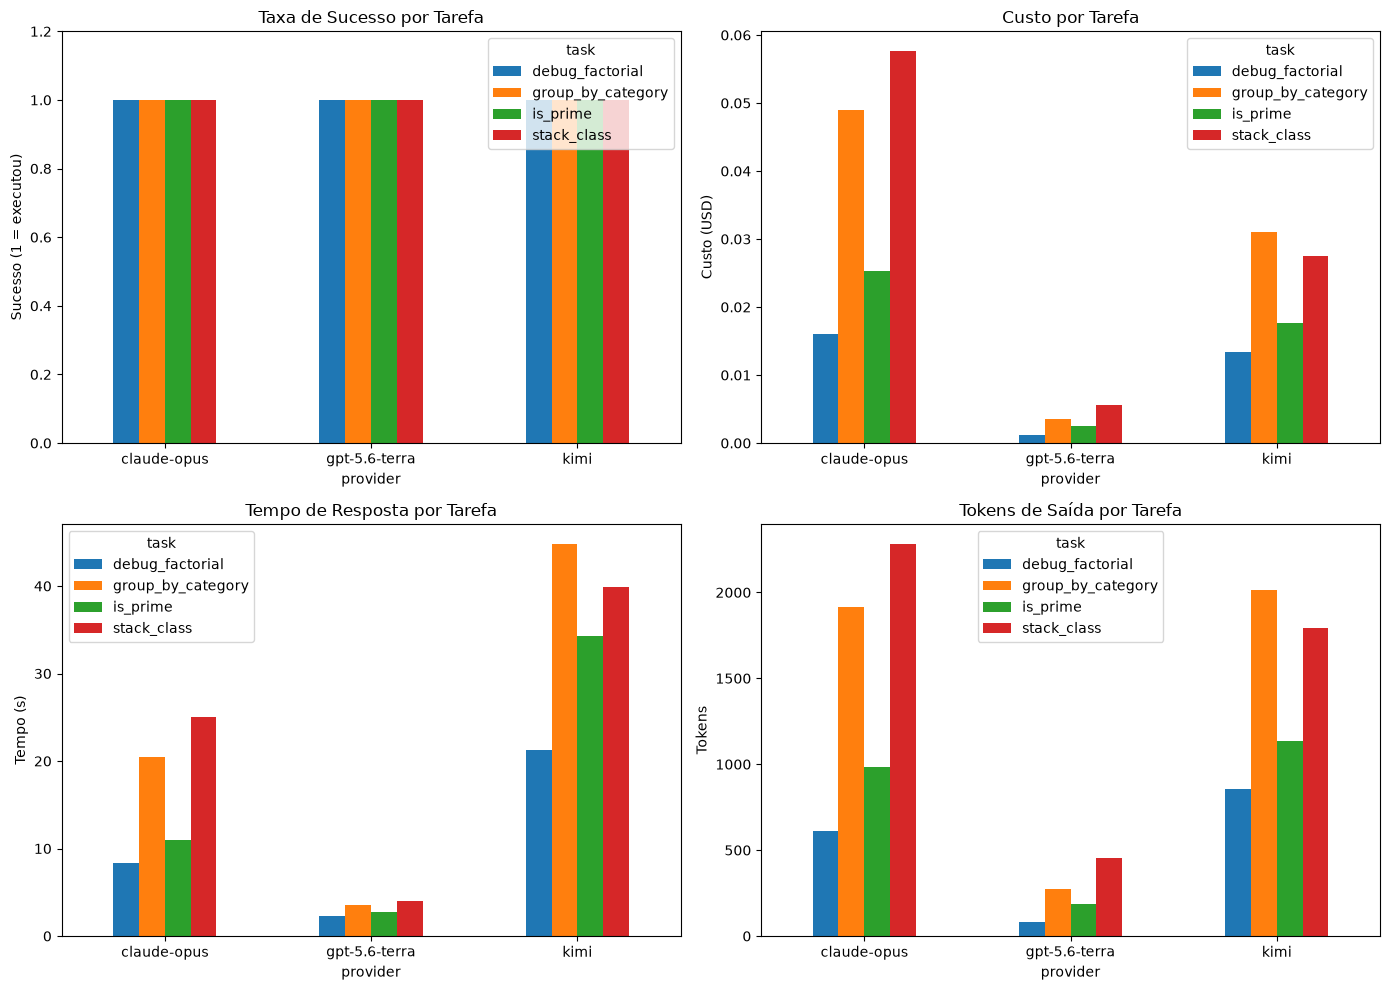

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Taxa de sucesso por tarefa
# .astype(float): execution_success é booleano e o pandas não plota bool como dado
# numérico ("no numeric data to plot"). float também aceita NaN, caso algum par
# provider x tarefa não exista no DataFrame.
success_pivot = df_all.pivot(index="provider", columns="task", values="execution_success").astype(float)
success_pivot.plot.bar(ax=axes[0, 0], title="Taxa de Sucesso por Tarefa", rot=0)
axes[0, 0].set_ylabel("Sucesso (1 = executou)")
axes[0, 0].set_ylim(0, 1.2)

# Custo por tarefa
cost_pivot = df_all.pivot(index="provider", columns="task", values="cost_usd")
cost_pivot.plot.bar(ax=axes[0, 1], title="Custo por Tarefa", rot=0)
axes[0, 1].set_ylabel("Custo (USD)")

# Tempo por tarefa
time_pivot = df_all.pivot(index="provider", columns="task", values="time_seconds")
time_pivot.plot.bar(ax=axes[1, 0], title="Tempo de Resposta por Tarefa", rot=0)
axes[1, 0].set_ylabel("Tempo (s)")

# Tokens de saída por tarefa
token_pivot = df_all.pivot(index="provider", columns="task", values="output_tokens")
token_pivot.plot.bar(ax=axes[1, 1], title="Tokens de Saída por Tarefa", rot=0)
axes[1, 1].set_ylabel("Tokens")

plt.tight_layout()
plt.show()

## 12. Score final por provider

In [23]:
summary = df_all.groupby("provider").agg(
    total_tasks=("task", "count"),
    successful_tasks=("execution_success", "sum"),
    avg_time=("time_seconds", "mean"),
    total_cost=("cost_usd", "sum"),
    total_tokens=("total_tokens", "sum")
).reset_index()
summary["success_rate"] = summary["successful_tasks"] / summary["total_tasks"]
summary = summary.round(4)
summary

,provider,total_tasks,successful_tasks,avg_time,total_cost,total_tokens,success_rate
0,claude-opus,4,4,16.2054,0.1480,6453,1.0
1,gpt-5.6-terra,4,4,3.1434,0.0129,1439,1.0
2,kimi,4,4,35.0615,0.0895,6636,1.0


## 13. Exportação

In [24]:
# Métricas (planilha enxuta) + respostas/códigos completos em arquivo separado
metrics(df_all).to_csv("benchmark_codigo_resultados.csv", index=False)
summary.to_csv("benchmark_codigo_resumo.csv", index=False)
df_all.to_csv("benchmark_codigo_respostas.csv", index=False)
print("Resultados salvos em benchmark_codigo_resultados.csv e benchmark_codigo_resumo.csv")
print("Respostas e códigos completos em benchmark_codigo_respostas.csv")


Resultados salvos em benchmark_codigo_resultados.csv e benchmark_codigo_resumo.csv
Respostas e códigos completos em benchmark_codigo_respostas.csv


## 14. Perguntas para análise

1. Qual modelo gerou o maior número de códigos executáveis?
2. Qual modelo foi mais rápido? E o mais barato?
3. Houve algum erro recorrente (sintaxe, imports, lógica)?
4. Em qual tarefa o Kimi se saiu melhor ou pior comparado aos concorrentes?